# Long-Term Orbit Validation: Landsat 9

Mission analyses often span months or years, longer than a single two-line element (TLE) set remains accurate. Operational satellites in repeat ground track orbits are maintained: small maneuvers counter atmospheric drag (which lowers the orbit) and, for sun-synchronous orbits, the Sun's gravity (which changes the inclination and so the local time of the orbit). TAT-C can model such a maintained orbit from a single TLE by propagating it without drag (`remove_drag=True`) and repeating its first repeat cycle (a declared `repeat_cycle`, or `repeat_cycle="auto"` for a repeat cycle detected by `get_repeat_cycle`); by default, TAT-C propagates the TLE directly with SGP4. This notebook compares TAT-C's propagations of one TLE of [Landsat 9](https://www.usgs.gov/landsat-missions/landsat-9) with the satellite's actual orbit over 19 months (1 March 2025 to 5 October 2026), and asks:

1. **Orbit maintenance.** How is Landsat 9's orbit maintained?
2. **Propagation.** How closely do TAT-C's propagations of the first TLE follow Landsat 9's ground track, timing, and local time over 19 months?
3. **Observations.** How accurately do they predict the observations of points by Landsat 9's Operational Land Imager (OLI)?

## Reference Data

The history of Landsat 9's general perturbations element sets (2,046 TLEs from 1 March 2025 to 5 October 2026) is retrieved from [Space-Track.org](https://www.space-track.org/) (`gp_history` class for catalog number 49260), which requires a free account; its user agreement restricts the redistribution of these data, so they are not included with TAT-C. To run this notebook, save the history in three-line format as `data/orbits/landsat9_gp_history.tle`, for example from the query:

`https://www.space-track.org/basicspacedata/query/class/gp_history/NORAD_CAT_ID/49260/EPOCH/2025-03-01--2026-10-05/orderby/EPOCH%20asc/format/3le`

Each TLE represents the orbit near its epoch, so the history (as a multi-element `GeneralPerturbationsOrbit`, which propagates each time from the TLE with the nearest epoch) serves as the reference for the actual orbit.

In [1]:
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sgp4.api import Satrec

from tatc import utils
from tatc.analysis import collect_observations
from tatc.constants import timescale
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Point, Satellite

HISTORY_FILE = Path("data") / "orbits" / "landsat9_gp_history.tle"
if not HISTORY_FILE.exists():
    raise FileNotFoundError(f"Save the Landsat 9 TLE history from Space-Track.org as {HISTORY_FILE} (see above).")
lines = [line.rstrip() for line in HISTORY_FILE.read_text().splitlines() if line.strip()]
tles = [lines[i + 1 : i + 3] for i in range(0, len(lines), 3)]
rows = []
for tle in tles:
    satrec = Satrec.twoline2rv(*tle)
    rows.append(
        {
            "epoch": pd.Timestamp(satrec.jdsatepoch + satrec.jdsatepochF - 2440587.5, unit="D", tz="UTC"),
            "semimajor axis (km)": satrec.a * satrec.radiusearthkm,
            "inclination (deg)": np.degrees(satrec.inclo),
        }
    )
history = pd.DataFrame(rows)
history = history.assign(tle=tles).drop_duplicates("epoch").sort_values("epoch").reset_index(drop=True)
orbits = [GeneralPerturbationsOrbit.from_tle(tle) for tle in history.tle]
START, END = history.epoch.iloc[0], history.epoch.iloc[-1]
first = history.tle.iloc[0]
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})
pd.Series({"TLEs": len(tles), "unique epochs": len(history), "first epoch": f"{START:%Y-%m-%d %H:%M}", "last epoch": f"{END:%Y-%m-%d %H:%M}", "median interval (h)": history.epoch.diff().median() / pd.Timedelta(hours=1)})

TLEs                               2046
unique epochs                      1693
first epoch            2025-03-01 03:10
last epoch             2026-10-04 19:02
median interval (h)            6.592345
dtype: object

## Test 1: Orbit Maintenance

Each TLE's mean semimajor axis and inclination show the orbit's evolution: drag lowers the semimajor axis gradually and maneuvers raise it in steps, and the Sun's gravity changes the inclination, which inclination maneuvers restore. Maneuvers are detected as increases of the daily median semimajor axis by more than 30 m and changes of the daily median inclination by more than 0.01 deg. The local mean solar time of the ascending node (LTAN) is computed from each TLE's ascending node crossing, the first after its epoch (propagated by SGP4).

In [2]:
def ascending_node(orbit, time):
    """Time and longitude (deg) of an orbit's ascending node crossing nearest a time."""
    times = [time + timedelta(seconds=float(s)) for s in np.arange(-3000, 3000, 10)]
    position = orbit.get_geographic_position(times)
    latitude, longitude = position.latitude.degrees, position.longitude.degrees
    k = np.nonzero((latitude[:-1] < 0) & (latitude[1:] >= 0))[0]
    k = k[np.argmin(np.abs(k - len(times) // 2))]
    fraction = -latitude[k] / (latitude[k + 1] - latitude[k])
    crossing = times[k] + (times[k + 1] - times[k]) * fraction
    step = (longitude[k + 1] - longitude[k] + 180) % 360 - 180
    return crossing, (longitude[k] + fraction * step + 180) % 360 - 180


def ltan(time, longitude):
    """Local mean solar time (h) of a crossing."""
    return (time.hour + time.minute / 60 + (time.second + time.microsecond / 1e6) / 3600 + longitude / 15) % 24


# reference crossings: one per day, from the TLE closest to noon
days = pd.date_range(START.normalize() + pd.Timedelta(days=1), END.normalize(), freq="D", tz="UTC")
reference = sorted({int(np.argmin(np.abs((history.epoch - (d + pd.Timedelta(hours=12))).dt.total_seconds()))) for d in days})
nodes = []
for i in reference:
    time, longitude = ascending_node(orbits[i], (history.epoch[i] + pd.Timedelta(minutes=50)).floor("us").to_pydatetime())
    nodes.append({"time": time, "longitude": longitude, "LTAN (h)": ltan(time, longitude)})
nodes = pd.DataFrame(nodes)
nodes["elapsed (days)"] = (pd.to_datetime(nodes.time) - START) / pd.Timedelta(days=1)

daily = history.set_index("epoch")[["semimajor axis (km)", "inclination (deg)"]].resample("D").median().dropna()
burns = daily[daily["semimajor axis (km)"].diff() > 0.030]
inclination_maneuvers = daily[daily["inclination (deg)"].diff().abs() > 0.01]
drift = daily["inclination (deg)"].diff()[daily["inclination (deg)"].diff().abs() < 0.005].mean() * 365.25
pd.Series(
    {
        "semimajor axis, range (km)": f"{history['semimajor axis (km)'].min():.3f} to {history['semimajor axis (km)'].max():.3f}",
        "semimajor axis maneuvers (daily increase > 30 m)": len(burns),
        "semimajor axis maneuvers, median increase (m)": 1e3 * daily["semimajor axis (km)"].diff()[burns.index].median(),
        "inclination maneuvers": ", ".join(f"{t:%Y-%m-%d} ({daily['inclination (deg)'].diff()[t]:+.3f} deg)" for t in inclination_maneuvers.index),
        "inclination drift between maneuvers (deg/yr)": drift,
        "LTAN, range (minutes after 22:00)": f"{(nodes['LTAN (h)'].min() - 22) * 60:.2f} to {(nodes['LTAN (h)'].max() - 22) * 60:.2f}",
    }
)

semimajor axis, range (km)                                                      7077.615 to 7077.816
semimajor axis maneuvers (daily increase > 30 m)                                                  23
semimajor axis maneuvers, median increase (m)                                              74.916447
inclination maneuvers                               2025-05-30 (+0.039 deg), 2026-06-06 (+0.042 deg)
inclination drift between maneuvers (deg/yr)                                               -0.040818
LTAN, range (minutes after 22:00)                                                     11.54 to 12.70
dtype: object

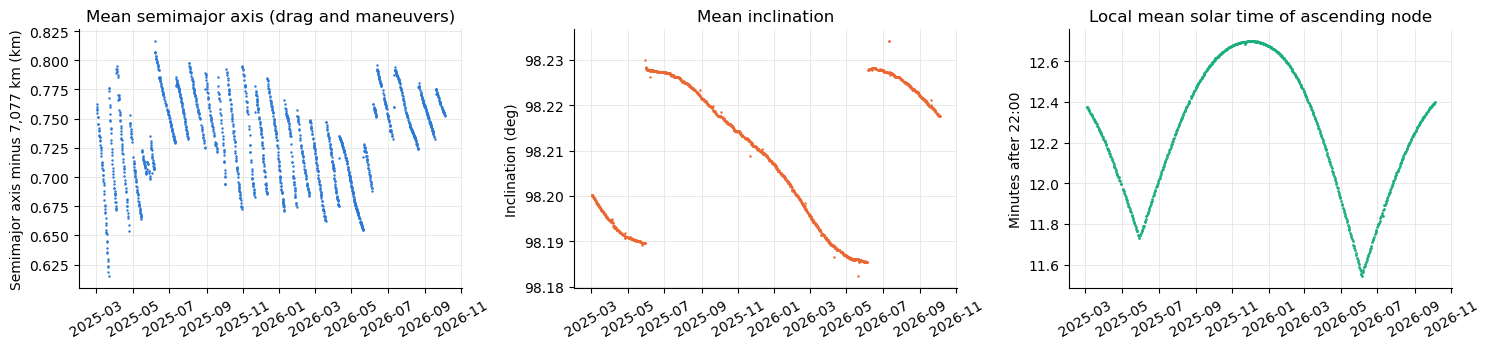

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(history.epoch, history["semimajor axis (km)"] - 7077, ".", ms=1.5, color=BLUE)
axes[0].set(ylabel="Semimajor axis minus 7,077 km (km)", title="Mean semimajor axis (drag and maneuvers)")
axes[1].plot(history.epoch, history["inclination (deg)"], ".", ms=1.5, color=ORANGE)
axes[1].set(ylabel="Inclination (deg)", title="Mean inclination")
axes[2].plot(pd.to_datetime(nodes.time), nodes["LTAN (h)"] * 60 - 22 * 60, ".", ms=2, color=AQUA)
axes[2].set(ylabel="Minutes after 22:00", title="Local mean solar time of ascending node")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

Landsat 9's orbit is maintained in two ways. Drag lowers the mean semimajor axis by a few meters per day, and 23 maneuvers over the 19 months (one every three to four weeks) raise it by about 75 m, keeping it within 200 m (7,077.62 to 7,077.82 km). The Sun's gravity lowers the inclination by about 0.04 deg per year, which, by changing the precession of the orbit plane, would let the local time of the orbit drift; two inclination maneuvers (on 30 May 2025 and 6 June 2026, of +0.04 deg each) restore it. As a result, the local mean solar time of the ascending node stays within 1.2 minutes (22:11:32 to 22:12:42; the descending node, when Landsat images, crosses at 10:12), oscillating with a period of a year between the inclination maneuvers.

## Test 2: Propagation

Four TAT-C propagations of the first TLE (1 March 2025) are compared with the daily reference crossings of Test 1. For each, the ascending node crossing nearest each reference crossing is found, and the differences of their times, longitudes (expressed as a distance at the equator, a measure of the ground track's offset), and LTANs are computed:

* **SGP4**: the TLE propagated directly (the default, `repeat_cycle=None`);
* **SGP4 without drag**: propagated directly with `remove_drag=True`;
* **detected repeat cycle**: `remove_drag=True` and `repeat_cycle="auto"`, with the repeat cycle detected by `get_repeat_cycle` (verified without drag and rounded to whole mean solar days for this sun-synchronous orbit), propagated maintained on its repeat ground track;
* **declared repeat cycle**: `remove_drag=True` and a declared `repeat_cycle` of 16 days (refined to whole mean solar days for this sun-synchronous orbit), also propagated maintained on its repeat ground track.

When a propagation's crossings fall more than half an orbit from the reference's, the nearest crossing belongs to another orbit; these are excluded.

In [4]:
import warnings

# the SGP4 models propagate the first TLE directly, with drag, for 19 months on purpose
warnings.filterwarnings("ignore", message="Propagating general perturbations elements with drag")
models = {
    "SGP4": GeneralPerturbationsOrbit.from_tle(first),
    "SGP4 without drag": GeneralPerturbationsOrbit.from_tle(first, remove_drag=True),
    "detected repeat cycle": GeneralPerturbationsOrbit.from_tle(first, remove_drag=True, repeat_cycle="auto"),
    "declared repeat cycle": GeneralPerturbationsOrbit.from_tle(first, remove_drag=True, repeat_cycle=timedelta(days=16)),
}
period = orbits[0].get_orbit_period().total_seconds()
for name, orbit in models.items():
    offsets = []
    for reference_time, reference_longitude, reference_ltan in zip(nodes.time, nodes.longitude, nodes["LTAN (h)"]):
        time, longitude = ascending_node(orbit, reference_time)
        offsets.append(((time - reference_time).total_seconds(), ((longitude - reference_longitude + 180) % 360 - 180) * 111.32, (ltan(time, longitude) - reference_ltan) * 60))
    offsets = np.array(offsets)
    valid = np.abs(offsets[:, 0]) < period / 2 - 60
    nodes[f"{name}: time (s)"] = np.where(valid, offsets[:, 0], np.nan)
    nodes[f"{name}: ground track (km)"] = np.where(valid, offsets[:, 1], np.nan)
    nodes[f"{name}: LTAN (min)"] = np.where(valid, offsets[:, 2], np.nan)
print("repeat cycles:", {name: str(orbit.get_repeat_cycle()) for name, orbit in models.items() if orbit.repeat_cycle is not None})
bins = pd.cut(nodes["elapsed (days)"], [0, 30, 91, 182, 365, 600], labels=["first month", "1 to 3 months", "3 to 6 months", "6 to 12 months", "12 to 19 months"])
table2 = {}
for name in models:
    for quantity in ["time (s)", "ground track (km)"]:
        column = nodes[f"{name}: {quantity}"]
        table2[(name, f"{quantity}, max |x|")] = column.abs().groupby(bins, observed=False).max()
        table2[(name, "excluded (%)")] = 100 * column.isna().groupby(bins, observed=False).mean()
pd.DataFrame(table2).T.round(1)

repeat cycles: {'detected repeat cycle': '16 days, 0:00:00', 'declared repeat cycle': '16 days, 0:00:00'}


elapsed (days)                                    first month  1 to 3 months  \
SGP4                  time (s), max |x|                  41.8          556.0   
                      excluded (%)                        0.0            0.0   
                      ground track (km), max |x|         19.8          264.2   
SGP4 without drag     time (s), max |x|                  26.9           79.4   
                      excluded (%)                        0.0            0.0   
                      ground track (km), max |x|         12.3           32.4   
detected repeat cycle time (s), max |x|                  13.0           36.6   
                      excluded (%)                        0.0            0.0   
                      ground track (km), max |x|          3.0            2.5   
declared repeat cycle time (s), max |x|                  13.0           36.6   
                      excluded (%)                        0.0            0.0   
                      ground track (km), max |x|          3.0            2.5   

elapsed (days)                                    3 to 6 months  \
SGP4                  time (s), max |x|                  2486.7   
                      excluded (%)                          0.0   
                      ground track (km), max |x|         1132.3   
SGP4 without drag     time (s), max |x|                    84.7   
                      excluded (%)                          0.0   
                      ground track (km), max |x|           66.9   
detected repeat cycle time (s), max |x|                    38.9   
                      excluded (%)                          0.0   
                      ground track (km), max |x|            1.7   
declared repeat cycle time (s), max |x|                    38.9   
                      excluded (%)                          0.0   
                      ground track (km), max |x|            1.7   

elapsed (days)                                    6 to 12 months  \
SGP4                  time (s), max |x|                   2901.7   
                      excluded (%)                           2.7   
                      ground track (km), max |x|          1371.6   
SGP4 without drag     time (s), max |x|                    168.4   
                      excluded (%)                           0.0   
                      ground track (km), max |x|           133.8   
detected repeat cycle time (s), max |x|                     22.1   
                      excluded (%)                           0.0   
                      ground track (km), max |x|             2.5   
declared repeat cycle time (s), max |x|                     22.1   
                      excluded (%)                           0.0   
                      ground track (km), max |x|             2.5   

elapsed (days)                                    12 to 19 months  
SGP4                  time (s), max |x|                    2896.4  
                      excluded (%)                            0.9  
                      ground track (km), max |x|           1347.2  
SGP4 without drag     time (s), max |x|                     274.7  
                      excluded (%)                            0.0  
                      ground track (km), max |x|            213.6  
detected repeat cycle time (s), max |x|                      49.8  
                      excluded (%)                            0.0  
                      ground track (km), max |x|              2.8  
declared repeat cycle time (s), max |x|                      49.8  
                      excluded (%)                            0.0  
                      ground track (km), max |x|              2.8

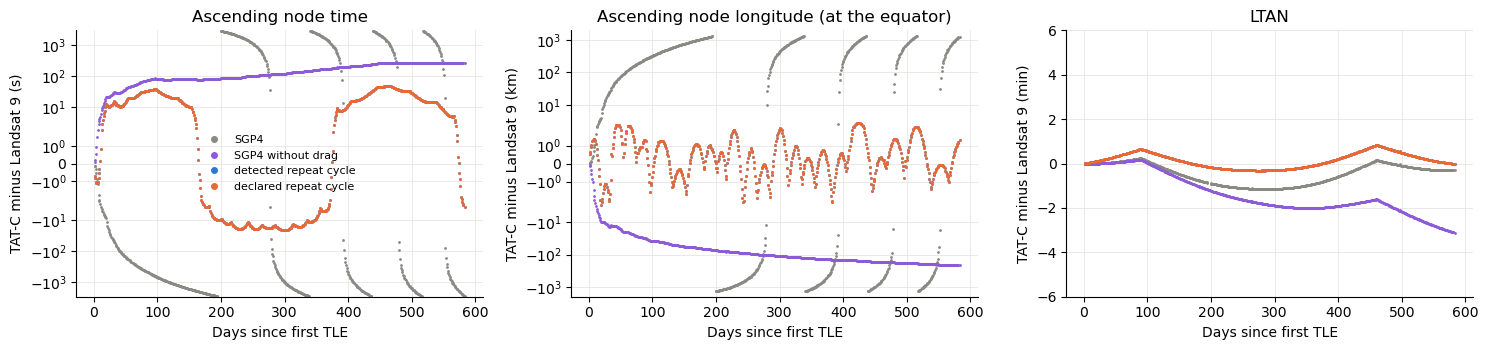

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
colors = dict(zip(models, [GRAY, PURPLE, BLUE, ORANGE]))
for name in models:
    axes[0].plot(nodes["elapsed (days)"], nodes[f"{name}: time (s)"], ".", ms=2, color=colors[name], label=name)
    axes[1].plot(nodes["elapsed (days)"], nodes[f"{name}: ground track (km)"], ".", ms=2, color=colors[name])
    axes[2].plot(nodes["elapsed (days)"], nodes[f"{name}: LTAN (min)"], ".", ms=2, color=colors[name])
axes[0].set(xlabel="Days since first TLE", ylabel="TAT-C minus Landsat 9 (s)", title="Ascending node time", yscale="symlog", ylim=(-3000, 3000))
axes[1].set(xlabel="Days since first TLE", ylabel="TAT-C minus Landsat 9 (km)", title="Ascending node longitude (at the equator)", yscale="symlog", ylim=(-2000, 2000))
axes[2].set(xlabel="Days since first TLE", ylabel="TAT-C minus Landsat 9 (min)", title="LTAN", ylim=(-6, 6))
axes[0].legend(frameon=False, fontsize=8, markerscale=4)
fig.tight_layout()
plt.show()

Propagated directly, the first TLE soon diverges from Landsat 9's orbit. With SGP4's drag, the satellite falls behind by 42 s within a month and by more than half an orbit after about 6 months, while drag makeup maneuvers keep the real orbit from decaying. Without drag, the satellite drifts more slowly (about 0.5 s per day), but its ground track drifts by 214 km over the 19 months, as the TLE's mean motion does not exactly repeat the ground track and its inclination, which SGP4 holds constant, does not follow the Sun's effect and the inclination maneuvers (its LTAN drifts by 3 minutes).

Repeating the first repeat cycle keeps the ground track, the timing, and the local time: both repeat-based propagations, whose repeat cycle is exactly 16 mean solar days (detected by `get_repeat_cycle`, or declared), stay within 3 km of Landsat 9's ground track at the equator, within 50 s of its timing, and within a minute of its LTAN over the 19 months; the remaining differences are the scatter of the TLE fits and of Landsat 9's own ground track and LTAN control. Both propagate the TLE maintained on its repeat ground track (`get_repeat_element`): without drag, with its mean motion adjusted so that 233 orbits span the 16 days exactly, and with its inclination adjusted (by 0.011 deg) so that its ascending node precesses with the mean Sun, as Landsat 9's inclination maneuvers keep it. (Before version 3.6, TAT-C reported the repeat cycle as the time when the satellite, propagated with drag, returned closest to its initial position, here 16 days minus 12.5 s, which accumulated to 7.5 minutes over the 19 months.) The two propagations are identical, as the detected repeat cycle is also exactly 16 days.

## Test 3: Observations

The points of interest are those of a Fibonacci lattice with a typical spacing of 3,000 km between 81 deg south and north. OLI is modeled with its 185 km swath from a 705 km altitude. For each point, `collect_observations` predicts its observations over the 19 months with the reference orbit (the multi-element TLE history) and with the detected and declared repeat cycle propagations of the first TLE (the direct propagations of Test 2 drift too far to be useful). Each reference observation is paired with the nearest predicted observation within 10 minutes; unpaired reference observations are missed, and unpaired predictions are extra.

In [6]:
oli = Instrument(name="OLI", field_of_regard=utils.swath_width_to_field_of_regard(705e3, 185e3))
lattice = generate_points_fibonacci_lattice(3000e3)
lattice = lattice[lattice.geometry.y.abs() < 81].reset_index(drop=True)
points = [Point(id=i, latitude=g.y, longitude=g.x) for i, g in enumerate(lattice.geometry)]
reference_orbit = GeneralPerturbationsOrbit.from_tle([line for tle in history.tle for line in tle])
predictions = {"reference": reference_orbit, "detected repeat cycle": models["detected repeat cycle"], "declared repeat cycle": models["declared repeat cycle"]}
start, end = (START + pd.Timedelta(hours=1)).floor("us").to_pydatetime(), END.floor("us").to_pydatetime()
observations = {}
for name, orbit in predictions.items():
    satellite = Satellite(name="Landsat 9", orbit=orbit, instruments=[oli])
    frames = Parallel(n_jobs=-1)(delayed(collect_observations)(point, satellite, start, end) for point in points)
    observations[name] = pd.concat([frame.assign(point_id=point.id) for point, frame in zip(points, frames)], ignore_index=True)
rows3 = {}
reference_obs = observations["reference"].sort_values("epoch")
for name in ["detected repeat cycle", "declared repeat cycle"]:
    predicted = observations[name].sort_values("epoch")
    pairs = pd.merge_asof(reference_obs[["point_id", "epoch"]], predicted[["point_id", "epoch"]].rename(columns={"epoch": "predicted"}), left_on="epoch", right_on="predicted", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=10))
    back = pd.merge_asof(predicted[["point_id", "epoch"]], reference_obs[["point_id", "epoch"]].rename(columns={"epoch": "actual"}), left_on="epoch", right_on="actual", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=10))
    error = (pairs.predicted - pairs.epoch).dt.total_seconds()
    elapsed = (pairs.epoch - START) / pd.Timedelta(days=1)
    rows3[name] = {
        "reference observations": len(pairs),
        "predicted (%)": 100 * pairs.predicted.notna().mean(),
        "extra predictions": int(back.actual.isna().sum()),
        "epoch error, median |x| (s)": error.abs().median(),
        "epoch error, p95 |x| (s)": error.abs().quantile(0.95),
        "epoch error in last 6 months, median (s)": error[elapsed > 400].median(),
    }
    observations[name + " pairs"] = pairs.assign(error=error, elapsed=elapsed)
pd.DataFrame(rows3).T.round(1)

,reference observations,predicted (%),extra predictions,"epoch error, median |x| (s)","epoch error, p95 |x| (s)","epoch error in last 6 months, median (s)"
detected repeat cycle,8241.0,99.4,49.0,15.6,41.1,18.7
declared repeat cycle,8241.0,99.4,49.0,15.6,41.1,18.7


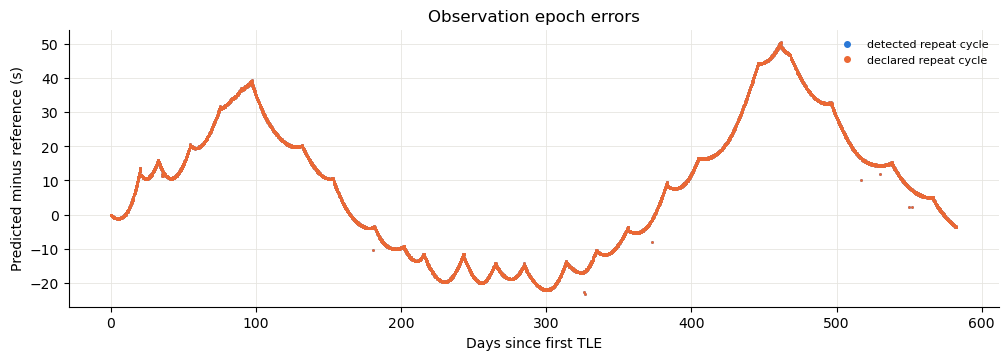

In [7]:
fig, ax = plt.subplots(figsize=(12, 3.6))
for name, color in [("detected repeat cycle", BLUE), ("declared repeat cycle", ORANGE)]:
    pairs = observations[name + " pairs"]
    ax.plot(pairs.elapsed, pairs.error, ".", ms=2, color=color, label=name)
ax.set(xlabel="Days since first TLE", ylabel="Predicted minus reference (s)", title="Observation epoch errors")
ax.legend(frameon=False, fontsize=8, markerscale=4)
plt.show()

Both repeat-based propagations predict 99.4% of the 8,241 observations of the reference orbit over the 19 months (the others, and 49 extra predictions, are at the swath edges, where ground track offsets of a few kilometers matter), and predict their times to within 16 s (median) and 41 s (95th percentile), without drift over the period.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit maintenance | 23 drag makeup maneuvers (about 75 m each) keep the semimajor axis within 200 m; two inclination maneuvers (+0.04 deg each) keep the LTAN within 1.2 minutes |
| 2. Propagation | direct SGP4 propagation diverges within months (with or without drag); repeating the first cycle of 16 mean solar days (detected or declared) keeps the ground track within 3 km and the timing within 50 s |
| 3. Observations | 99.4% of observations predicted by both repeat-based propagations, with epoch errors of 16 s (median) |

**Maintained orbits.** Over 19 months, Landsat 9 stays on its ground track and at its local time through routine maneuvers. A single TLE propagated directly cannot represent this, but repeating its first repeat cycle does: propagated as a maintained orbit (`remove_drag=True`) with the detected (`repeat_cycle="auto"`) or declared (`repeat_cycle=timedelta(days=16)`) repeat cycle, it reproduces Landsat 9's ground track (within 3 km), timing (within a minute), and observations over the whole period. Declaring the repeat cycle is needed for orbits whose repeat cycle cannot be detected from a TLE, such as the 91-day repeat cycle of [ICESat-2](ValidateLidarICESat2.ipynb).